**Libraries**

In [39]:
import argparse, warnings, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
matplotlib.use("inline")
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")


**Config**

In [3]:
DATA_PATH = "/content/data/gbpusd_hourly_newyorkTimezone.csv"
TARGET     = "close"
WINDOW     = 60
UNITS      = 64
DROPOUT    = 0.2
BATCH      = 32
EPOCHS     = 100
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
os.makedirs("results", exist_ok=True)

**Load Data**

In [4]:
df = pd.read_csv(DATA_PATH, skiprows=[0, 1])
df.columns = ['Datetime', 'Open', 'High', 'Low', 'Close']
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df = df.sort_values('Datetime').set_index('Datetime')
df = df[['Open', 'High', 'Low', 'Close']].astype(float).ffill().dropna()
print(f"Loaded {len(df):,} rows  {df.index[0].date()} → {df.index[-1].date()}")

Loaded 11,825 rows  2024-06-16 → 2026-05-15


**Features**

In [5]:
c = df["Close"]
df["Ret"]     = c.pct_change()
df["LogRet"]  = np.log(c / c.shift(1))
for w in [5, 10, 20]:   df[f"SMA{w}"] = c.rolling(w).mean()
for w in [10, 20, 50]:  df[f"EMA{w}"] = c.ewm(span=w, adjust=False).mean()
d = c.diff()
df["RSI"]     = 100 - 100 / (1 + d.clip(0).rolling(14).mean() /
                              (-d.clip(upper=0)).rolling(14).mean().replace(0, 1e-9))
df["MACD"]    = c.ewm(12, adjust=False).mean() - c.ewm(26, adjust=False).mean()
df["MACDsig"] = df["MACD"].ewm(9, adjust=False).mean()
mid = c.rolling(20).mean(); std = c.rolling(20).std()
df["BBw"]     = (4 * std) / (mid + 1e-9)
tr = pd.concat([df.High - df.Low,
                (df.High - c.shift()).abs(),
                (df.Low  - c.shift()).abs()], axis=1).max(axis=1)
df["ATR"]     = tr.rolling(14).mean()
df["HLr"]     = df.High - df.Low
df["Body"]    = (df.Close - df.Open).abs()
df.dropna(inplace=True)
cols = list(df.columns)
close_idx = cols.index("Close")
print(f"Features: {cols}")

Features: ['Open', 'High', 'Low', 'Close', 'Ret', 'LogRet', 'SMA5', 'SMA10', 'SMA20', 'EMA10', 'EMA20', 'EMA50', 'RSI', 'MACD', 'MACDsig', 'BBw', 'ATR', 'HLr', 'Body']


# **Preprocess**

**Handle Missing value**

In [6]:
missing_before = df.isnull().sum()
cols_with_nan  = missing_before[missing_before > 0]
if len(cols_with_nan):
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    filled = cols_with_nan.sum()
    print(f"\n  Missing values")
    print(f"       Columns affected : {list(cols_with_nan.index)}")
    print(f"       Total cells filled: {filled}")
else:
    print(f"\n  Missing values     → none found, data is clean")


  Missing values     → none found, data is clean


**DUPLICATE TIMESTAMP REMOVAL**

In [7]:
dupes = df.index.duplicated().sum()
if dupes:
    df = df[~df.index.duplicated(keep="first")]
    print(f"\n  Duplicate rows     → removed {dupes} duplicates")
else:
    print(f"  Duplicate rows     → none found")

  Duplicate rows     → none found


**OUTLIER REMOVAL**

In [8]:
# IQR on log returns
before = len(df)
lr   = df["LogRet"]
q1, q3 = lr.quantile(0.25), lr.quantile(0.75)
iqr  = q3 - q1
mask = (lr >= q1 - 4*iqr) & (lr <= q3 + 4*iqr)
df   = df[mask]
removed = before - len(df)
print(f"\n Outlier removal    → removed {removed} rows "
      f"(log-return beyond 4×IQR)")
print(f"       IQR range kept    : [{q1 - 4*iqr:.6f},  {q3 + 4*iqr:.6f}]")
print(f"       Rows remaining    : {len(df):,}")


 Outlier removal    → removed 64 rows (log-return beyond 4×IQR)
       IQR range kept    : [-0.003769,  0.003789]
       Rows remaining    : 11,742


**Data SPLIT + SCALE + SEQUENCES**

In [9]:
n = len(df)
nt, nv = int(n * TRAIN_FRAC), int(n * VAL_FRAC)

sc = MinMaxScaler()
sc.fit(df.iloc[:nt])
scaled = pd.DataFrame(sc.transform(df), columns=cols, index=df.index)

def make_seqs(part):
    v = part.values; cl = part["Close"].values
    X, y = [], []
    for i in range(WINDOW, len(v)):
        X.append(v[i - WINDOW:i])
        y.append(cl[i] if TARGET == "close" else (1 if cl[i] > cl[i-1] else 0))
    return np.array(X, np.float32), np.array(y, np.float32)

Xtr, ytr = make_seqs(scaled.iloc[:nt])
Xvl, yvl = make_seqs(scaled.iloc[nt:nt + nv])
Xte, yte = make_seqs(scaled.iloc[nt + nv:])
print(f"Train {Xtr.shape} | Val {Xvl.shape} | Test {Xte.shape}")

Train (8159, 60, 19) | Val (1701, 60, 19) | Test (1702, 60, 19)


**HELPERS (models reuse them)**

In [14]:
def inv(v):
    tmp = np.zeros((len(v), len(cols))); tmp[:, close_idx] = v
    return sc.inverse_transform(tmp)[:, close_idx]

class Attention(layers.Layer):
    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(
            name="W",
            shape=(d, d),
            initializer="glorot_uniform",
            trainable=True
        )
        self.v = self.add_weight(
            name="v",
            shape=(d, 1),
            initializer="glorot_uniform",
            trainable=True
        )
        super().build(input_shape)

    def call(self, h):
        score = tf.nn.tanh(
            tf.tensordot(h, self.W, axes=[[2], [0]])
        )
        weight = tf.nn.softmax(
            tf.tensordot(score, self.v, axes=[[2], [0]]),
            axis=1
        )
        return tf.reduce_sum(weight * h, axis=1)

sh   = (Xtr.shape[1], Xtr.shape[2])
out  = lambda x: layers.Dense(1)(x) if TARGET=="close" else layers.Dense(1, activation="sigmoid")(x)
loss = "mse" if TARGET == "close" else "binary_crossentropy"
cbs  = lambda: [EarlyStopping("val_loss", patience=15, restore_best_weights=True),
                ReduceLROnPlateau("val_loss", factor=0.5, patience=7, min_lr=1e-6)]

**Models**

In [23]:
i = Input(sh)
x = layers.LSTM(UNITS, return_sequences=True)(i)
x = layers.Dropout(DROPOUT)(x)
x = layers.LSTM(UNITS)(x)
x = layers.Dropout(DROPOUT)(x)
lstm = Model(i, layers.Dense(1)(x), name="LSTM")
lstm.compile("adam", "mse")

i = Input(sh)
x = layers.Bidirectional(layers.LSTM(UNITS, return_sequences=True))(i)
x = layers.Dropout(DROPOUT)(x)
x = layers.Bidirectional(layers.LSTM(UNITS // 2))(x)
x = layers.Dropout(DROPOUT)(x)
bilstm = Model(i, layers.Dense(1)(x), name="BiLSTM")
bilstm.compile("adam", "mse")

i = Input(sh)
x = layers.GRU(UNITS, return_sequences=True)(i)
x = layers.Dropout(DROPOUT)(x)
x = layers.GRU(UNITS)(x)
x = layers.Dropout(DROPOUT)(x)
gru = Model(i, layers.Dense(1)(x), name="GRU")
gru.compile("adam", "mse")

i = Input(sh)
x = layers.Conv1D(64, 3, activation="relu", padding="same")(i)
x = layers.MaxPooling1D(2)(x)
x = layers.Dropout(DROPOUT)(x)
x = layers.Bidirectional(layers.LSTM(UNITS, return_sequences=True))(x)
x = layers.Dropout(DROPOUT)(x)
x = Attention()(x)
x = layers.Dense(32, activation="relu")(x)
cnn_attn = Model(i, layers.Dense(1)(x), name="CNN_BiLSTM_Attn")
cnn_attn.compile("adam", "mse")

In [56]:
cbs= [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

# **LSTM**

**Train**

In [21]:
print("\n Training LSTM...")

h_lstm = lstm.fit(
         Xtr, ytr,
         validation_data=(Xvl, yvl),
         epochs=EPOCHS,
         batch_size=BATCH,
         callbacks=cbs,
         verbose=1
  )


 Training LSTM...
Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0070 - val_loss: 2.9354e-04 - learning_rate: 0.0010
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0026 - val_loss: 3.0502e-04 - learning_rate: 0.0010
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0022 - val_loss: 3.1971e-04 - learning_rate: 0.0010
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0021 - val_loss: 4.8504e-04 - learning_rate: 0.0010
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - val_loss: 3.7614e-04 - learning_rate: 0.0010
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0017 - val_loss: 2.3299e-04 - learning_rate: 0.0010
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0016 - val_loss: 3.3691e-04 - learning_rate: 0.0010
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0013 - val_loss: 3.9546e-04 - learning_rate: 0.0010
Epoch 9/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

**Learning Curve**

Best epoch=80  val_loss=0.000048


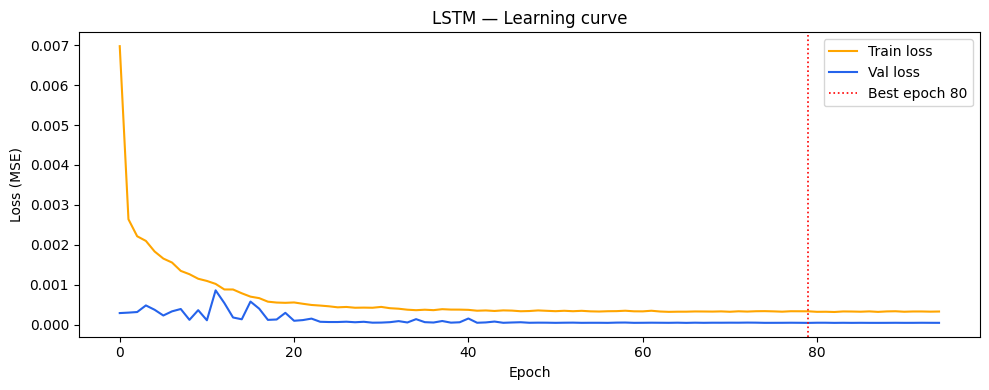

In [40]:
best_ep_lstm = np.argmin(h_lstm.history["val_loss"])
print(f"Best epoch={best_ep_lstm+1}  val_loss={min(h_lstm.history['val_loss']):.6f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_lstm.history["loss"],     label="Train loss", color="orange", lw=1.5)
ax.plot(h_lstm.history["val_loss"], label="Val loss",   color="#2563EB", lw=1.5)
ax.axvline(best_ep_lstm, color="red", linestyle=":", lw=1.2, label=f"Best epoch {best_ep_lstm+1}")
ax.set(xlabel="Epoch", ylabel="Loss (MSE)", title="LSTM — Learning curve")
ax.legend(); plt.tight_layout(); plt.show()

**TEST**

In [26]:
p_lstm      = lstm.predict(Xte, verbose=0).flatten()
yt          = yte.flatten()
actual_lstm = inv(yt)
pred_lstm   = inv(p_lstm)

# Metrics
rmse_lstm = np.sqrt(mean_squared_error(yt, p_lstm))
mae_lstm  = mean_absolute_error(yt, p_lstm)
mape_lstm = np.mean(np.abs((yt - p_lstm) / (np.abs(yt) + 1e-9))) * 100
r2_lstm   = r2_score(yt, p_lstm)
da_lstm   = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(p_lstm))) * 100
print(f"RMSE={rmse_lstm:.5f}  MAE={mae_lstm:.5f}  MAPE={mape_lstm:.2f}%  R2={r2_lstm:.4f}  DA={da_lstm:.1f}%")

RMSE=0.00968  MAE=0.00628  MAPE=0.79%  R2=0.9834  DA=48.6%


**Backtest**

In [41]:
sig_lstm    = np.sign(np.diff(pred_lstm))
ret_lstm    = np.diff(actual_lstm) / (actual_lstm[:-1] + 1e-9)
pnl_lstm    = sig_lstm * ret_lstm
equity_lstm = (1 + pnl_lstm).cumprod()
win_lstm    = (pnl_lstm > 0).mean() * 100
tot_lstm    = (equity_lstm[-1] - 1) * 100
dd_lstm     = ((equity_lstm - np.maximum.accumulate(equity_lstm)) /
               (np.maximum.accumulate(equity_lstm) + 1e-9)).min() * 100
print(f"WinRate={win_lstm:.1f}%  Return={tot_lstm:.2f}%  MaxDD={dd_lstm:.2f}%")

WinRate=48.6%  Return=-3.61%  MaxDD=-6.84%


**Plots**

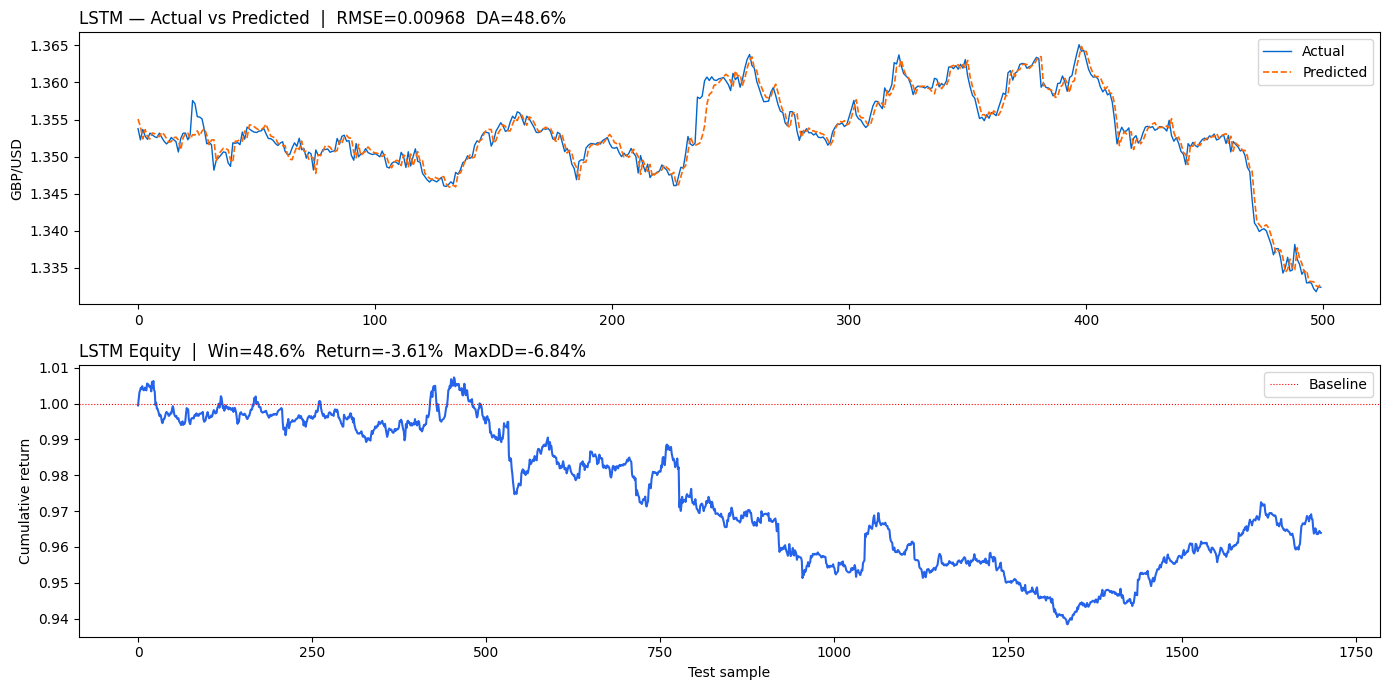

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot 1: Actual vs Predicted
axes[0].plot(actual_lstm[-500:], color="#0066cc", lw=1,   label="Actual")
axes[0].plot(pred_lstm[-500:],   color="#ff6600", lw=1.2, label="Predicted", linestyle="--")
axes[0].set_title(f"LSTM — Actual vs Predicted  |  RMSE={rmse_lstm:.5f}  DA={da_lstm:.1f}%", loc="left")
axes[0].set_ylabel("GBP/USD"); axes[0].legend()

# Plot 2: Equity curve
axes[1].plot(equity_lstm, color="#2563EB", lw=1.5)
axes[1].axhline(1.0, color="red", linestyle=":", lw=0.8, label="Baseline")
axes[1].set_title(f"LSTM Equity  |  Win={win_lstm:.1f}%  Return={tot_lstm:.2f}%  MaxDD={dd_lstm:.2f}%", loc="left")
axes[1].set_ylabel("Cumulative return"); axes[1].set_xlabel("Test sample")
axes[1].legend()

plt.tight_layout()
plt.show()

# **BiLSTM**

**Train**

In [57]:
print("Training BiLSTM...")
h_bilstm = bilstm.fit(
            Xtr, ytr,
            validation_data=(Xvl, yvl),
            epochs=EPOCHS,
            batch_size=BATCH,
            callbacks=cbs,
            verbose=1)
best_ep_bilstm = np.argmin(h_bilstm.history["val_loss"])
print(f"Best epoch={best_ep_bilstm+1}  val_loss={min(h_bilstm.history['val_loss']):.6f}")

Training BiLSTM...
Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.0086 - val_loss: 3.8965e-04 - learning_rate: 0.0010
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0029 - val_loss: 3.7449e-04 - learning_rate: 0.0010
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0025 - val_loss: 5.7701e-04 - learning_rate: 0.0010
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0022 - val_loss: 1.7813e-04 - learning_rate: 0.0010
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0019 - val_loss: 3.3012e-04 - learning_rate: 0.0010
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0017 - val_loss: 2.1946e-04 - learning_rate: 0.0010
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0015 - val_loss: 1.5529e-04 - learning_rate: 0.0010
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0015 - val_loss: 3.1894e-04 - learning_rate: 0.0010
Epoch 9/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/st

**Training Curve**

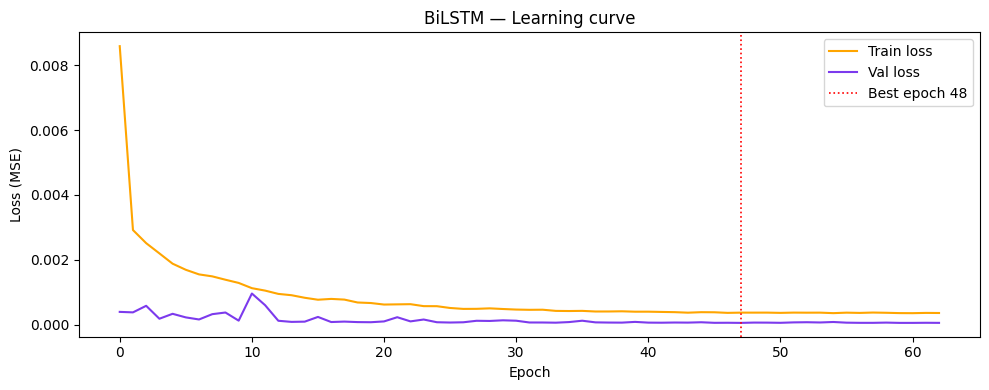

In [59]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_bilstm.history["loss"],     label="Train loss", color="orange", lw=1.5)
ax.plot(h_bilstm.history["val_loss"], label="Val loss",   color="#7C3AED", lw=1.5)
ax.axvline(best_ep_bilstm, color="red", linestyle=":", lw=1.2, label=f"Best epoch {best_ep_bilstm+1}")
ax.set(xlabel="Epoch", ylabel="Loss (MSE)", title="BiLSTM — Learning curve")
ax.legend(); plt.tight_layout(); plt.show()

**Test**

In [60]:
p_bilstm      = bilstm.predict(Xte, verbose=0).flatten()
actual_bilstm = inv(yt); pred_bilstm = inv(p_bilstm)

rmse_bilstm = np.sqrt(mean_squared_error(yt, p_bilstm))
mae_bilstm  = mean_absolute_error(yt, p_bilstm)
mape_bilstm = np.mean(np.abs((yt - p_bilstm) / (np.abs(yt) + 1e-9))) * 100
r2_bilstm   = r2_score(yt, p_bilstm)
da_bilstm   = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(p_bilstm))) * 100
print(f"RMSE={rmse_bilstm:.5f}  MAE={mae_bilstm:.5f}  MAPE={mape_bilstm:.2f}%  R2={r2_bilstm:.4f}  DA={da_bilstm:.1f}%")

RMSE=0.00985  MAE=0.00669  MAPE=0.84%  R2=0.9828  DA=48.6%


**Backtest**

In [61]:
sig_bilstm    = np.sign(np.diff(pred_bilstm))
ret_bilstm    = np.diff(actual_bilstm) / (actual_bilstm[:-1] + 1e-9)
pnl_bilstm    = sig_bilstm * ret_bilstm
equity_bilstm = (1 + pnl_bilstm).cumprod()
win_bilstm    = (pnl_bilstm > 0).mean() * 100
tot_bilstm    = (equity_bilstm[-1] - 1) * 100
dd_bilstm     = ((equity_bilstm - np.maximum.accumulate(equity_bilstm)) /
                 (np.maximum.accumulate(equity_bilstm) + 1e-9)).min() * 100
print(f"WinRate={win_bilstm:.1f}%  Return={tot_bilstm:.2f}%  MaxDD={dd_bilstm:.2f}%")

WinRate=48.6%  Return=-4.81%  MaxDD=-8.66%


**Plots**

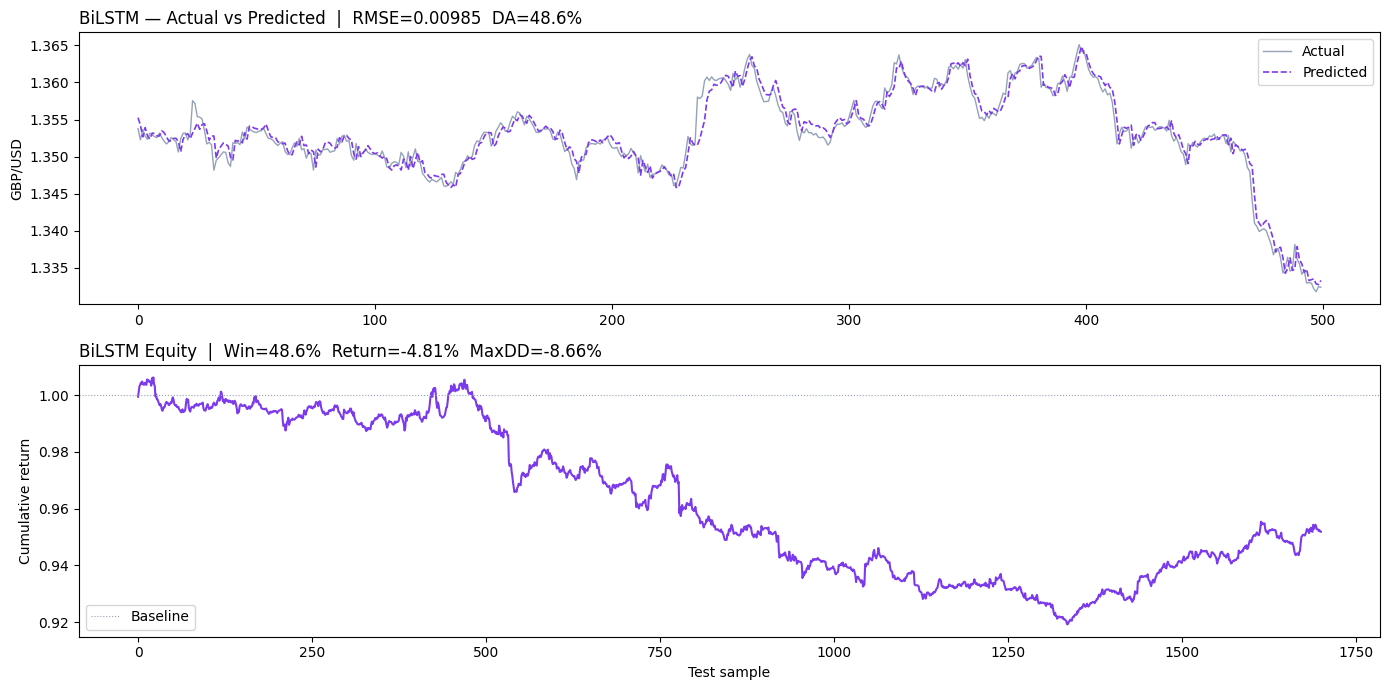

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(actual_bilstm[-500:], color="#94A3B8", lw=1,   label="Actual")
axes[0].plot(pred_bilstm[-500:],   color="#7C3AED", lw=1.2, label="Predicted", linestyle="--")
axes[0].set_title(f"BiLSTM — Actual vs Predicted  |  RMSE={rmse_bilstm:.5f}  DA={da_bilstm:.1f}%", loc="left")
axes[0].set_ylabel("GBP/USD"); axes[0].legend()
axes[1].plot(equity_bilstm, color="#7C3AED", lw=1.5)
axes[1].axhline(1.0, color="#94A3B8", linestyle=":", lw=0.8, label="Baseline")
axes[1].set_title(f"BiLSTM Equity  |  Win={win_bilstm:.1f}%  Return={tot_bilstm:.2f}%  MaxDD={dd_bilstm:.2f}%", loc="left")
axes[1].set_ylabel("Cumulative return"); axes[1].set_xlabel("Test sample")
axes[1].legend(); plt.tight_layout(); plt.show()

# **GRU**

**Train**

In [ ]:
print("Training GRU...")
h_gru = gru.fit(Xtr, ytr, validation_data=(Xvl, yvl),
                epochs=EPOCHS, batch_size=BATCH, callbacks=make_cbs(), verbose=1)

best_ep_gru = np.argmin(h_gru.history["val_loss"])
print(f"Best epoch={best_ep_gru+1}  val_loss={min(h_gru.history['val_loss']):.6f}")

**Training Curve**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_gru.history["loss"],     label="Train loss", color="#94A3B8", lw=1.5)
ax.plot(h_gru.history["val_loss"], label="Val loss",   color="#059669", lw=1.5)
ax.axvline(best_ep_gru, color="red", linestyle=":", lw=1.2, label=f"Best epoch {best_ep_gru+1}")
ax.set(xlabel="Epoch", ylabel="Loss (MSE)", title="GRU — Learning curve")
ax.legend(); plt.tight_layout()
plt.show()

**Test**

In [ ]:
p_gru      = gru.predict(Xte, verbose=0).flatten()
actual_gru = inv(yt); pred_gru = inv(p_gru)

rmse_gru = np.sqrt(mean_squared_error(yt, p_gru))
mae_gru  = mean_absolute_error(yt, p_gru)
mape_gru = np.mean(np.abs((yt - p_gru) / (np.abs(yt) + 1e-9))) * 100
r2_gru   = r2_score(yt, p_gru)
da_gru   = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(p_gru))) * 100
print(f"RMSE={rmse_gru:.5f}  MAE={mae_gru:.5f}  MAPE={mape_gru:.2f}%  R2={r2_gru:.4f}  DA={da_gru:.1f}%")


**Backtest**

In [ ]:
sig_gru    = np.sign(np.diff(pred_gru))
ret_gru    = np.diff(actual_gru) / (actual_gru[:-1] + 1e-9)
pnl_gru    = sig_gru * ret_gru
equity_gru = (1 + pnl_gru).cumprod()
win_gru    = (pnl_gru > 0).mean() * 100
tot_gru    = (equity_gru[-1] - 1) * 100
dd_gru     = ((equity_gru - np.maximum.accumulate(equity_gru)) /
              (np.maximum.accumulate(equity_gru) + 1e-9)).min() * 100
print(f"WinRate={win_gru:.1f}%  Return={tot_gru:.2f}%  MaxDD={dd_gru:.2f}%")

**Plots**

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(actual_gru[-500:], color="#94A3B8", lw=1,   label="Actual")
axes[0].plot(pred_gru[-500:],   color="#059669", lw=1.2, label="Predicted", linestyle="--")
axes[0].set_title(f"GRU — Actual vs Predicted  |  RMSE={rmse_gru:.5f}  DA={da_gru:.1f}%", loc="left")
axes[0].set_ylabel("GBP/USD"); axes[0].legend()
axes[1].plot(equity_gru, color="#059669", lw=1.5)
axes[1].axhline(1.0, color="#94A3B8", linestyle=":", lw=0.8, label="Baseline")
axes[1].set_title(f"GRU Equity  |  Win={win_gru:.1f}%  Return={tot_gru:.2f}%  MaxDD={dd_gru:.2f}%", loc="left")
axes[1].set_ylabel("Cumulative return"); axes[1].set_xlabel("Test sample")
axes[1].legend(); plt.tight_layout()
plt.show()

# **CNN_BiLSTM_Attn**

**Train**

In [ ]:
print("Training CNN_BiLSTM_Attn...")
h_cnn = cnn_attn.fit(Xtr, ytr, validation_data=(Xvl, yvl),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=make_cbs(), verbose=1)

best_ep_cnn = np.argmin(h_cnn.history["val_loss"])
print(f"Best epoch={best_ep_cnn+1}  val_loss={min(h_cnn.history['val_loss']):.6f}")

**Training Curve**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_cnn.history["loss"],     label="Train loss", color="#94A3B8", lw=1.5)
ax.plot(h_cnn.history["val_loss"], label="Val loss",   color="#D97706", lw=1.5)
ax.axvline(best_ep_cnn, color="red", linestyle=":", lw=1.2, label=f"Best epoch {best_ep_cnn+1}")
ax.set(xlabel="Epoch", ylabel="Loss (MSE)", title="CNN_BiLSTM_Attn — Learning curve")
ax.legend(); plt.tight_layout()
plt.show()

**Test**

In [ ]:
p_cnn      = cnn_attn.predict(Xte, verbose=0).flatten()
actual_cnn = inv(yt); pred_cnn = inv(p_cnn)

rmse_cnn = np.sqrt(mean_squared_error(yt, p_cnn))
mae_cnn  = mean_absolute_error(yt, p_cnn)
mape_cnn = np.mean(np.abs((yt - p_cnn) / (np.abs(yt) + 1e-9))) * 100
r2_cnn   = r2_score(yt, p_cnn)
da_cnn   = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(p_cnn))) * 100
print(f"RMSE={rmse_cnn:.5f}  MAE={mae_cnn:.5f}  MAPE={mape_cnn:.2f}%  R2={r2_cnn:.4f}  DA={da_cnn:.1f}%")

**Backtest**

In [ ]:
sig_cnn    = np.sign(np.diff(pred_cnn))
ret_cnn    = np.diff(actual_cnn) / (actual_cnn[:-1] + 1e-9)
pnl_cnn    = sig_cnn * ret_cnn
equity_cnn = (1 + pnl_cnn).cumprod()
win_cnn    = (pnl_cnn > 0).mean() * 100
tot_cnn    = (equity_cnn[-1] - 1) * 100
dd_cnn     = ((equity_cnn - np.maximum.accumulate(equity_cnn)) /
              (np.maximum.accumulate(equity_cnn) + 1e-9)).min() * 100
print(f"WinRate={win_cnn:.1f}%  Return={tot_cnn:.2f}%  MaxDD={dd_cnn:.2f}%")

**Plots**

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(actual_cnn[-500:], color="#94A3B8", lw=1,   label="Actual")
axes[0].plot(pred_cnn[-500:],   color="#D97706", lw=1.2, label="Predicted", linestyle="--")
axes[0].set_title(f"CNN_BiLSTM_Attn — Actual vs Predicted  |  RMSE={rmse_cnn:.5f}  DA={da_cnn:.1f}%", loc="left")
axes[0].set_ylabel("GBP/USD"); axes[0].legend()
axes[1].plot(equity_cnn, color="#D97706", lw=1.5)
axes[1].axhline(1.0, color="#94A3B8", linestyle=":", lw=0.8, label="Baseline")
axes[1].set_title(f"CNN_BiLSTM_Attn Equity  |  Win={win_cnn:.1f}%  Return={tot_cnn:.2f}%  MaxDD={dd_cnn:.2f}%", loc="left")
axes[1].set_ylabel("Cumulative return"); axes[1].set_xlabel("Test sample")
axes[1].legend(); plt.tight_layout()
plt.show()